## <font color='tomato'>I. Data Discovering</font>

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from IPython.display import Image
from IPython.display import HTML

#functions
#format numbers in a more readable way
def format_number(x):
    if x >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    elif x >= 1_000:
        return f"{x/1_000:.1f}K"
    else:
        return str(round(x, 2))

file_path = "../data/ecommerce_data.csv"

df = pd.read_csv(file_path, encoding="ISO-8859-1")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [108]:
print('The shape of the dataset is:', df.shape)
print('The columns in the dataset are:', df.columns.tolist())


The shape of the dataset is: (541909, 8)
The columns in the dataset are: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [109]:
print('Dataset Info:\n----------------------------------------')
df.info()


Dataset Info:
----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [110]:
print('The number of missing values in each column is:')
df.isnull().sum()

The number of missing values in each column is:


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [111]:
print('The description of the dataset is:')
df.describe()

The description of the dataset is:


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [112]:
 # To analyze the number of items per invoice, I will group the data by "InvoiceNo" and count the number of items in each invoice.    
invoice_items = df.groupby("InvoiceNo").size().reset_index(name="ItemCount")
invoice_items.head()
# I noticed that the invoiceNo is repeated for multiple rows, which indicates that each row represents an item in the invoice.

,InvoiceNo,ItemCount
0,536365,7
1,536366,2
2,536367,12
3,536368,4
4,536369,1


#### **What does each row represent?**

Each row represents:
One product line item inside a customer invoice (transaction).

`More clearly:` 
One *customer* buys something, That purchase is recorded as multiple rows if multiple products are bought

Example from data:

InvoiceNo: **536365**

StockCode: **85123A**

Quantity: **6**

UnitPrice: **2.55**

*This means:* Customer bought 6 units of product 85123A in invoice 536365

Important insight (Obs): A single invoice (InvoiceNo) can appear *many times*. So, `1 invoice` = `full shopping basket`, and `many rows` = `items inside that basket`.

#### **Given that commercial transactions (buying and selling), what could be a “business transaction” here?**

A `business transaction` = `one invoice` (*InvoiceNo*), because:

An `invoice` *represents a full purchase event* by a `customer` at a *specific time*.

**Transaction level (correct business view)**

Group by `InvoiceNo` => That gives you `full purchase orders`.

**Example:** *invoice* `536365` contains **7** rows

In [113]:
df[df["InvoiceNo"] == "536365"][["InvoiceNo", "CustomerID", "InvoiceDate","StockCode", "Description", "Quantity", "UnitPrice"]]

,InvoiceNo,CustomerID,InvoiceDate,StockCode,Description,Quantity,UnitPrice
0,536365,17850.0,12/1/2010 8:26,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55
1,536365,17850.0,12/1/2010 8:26,71053,WHITE METAL LANTERN,6,3.39
2,536365,17850.0,12/1/2010 8:26,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75
3,536365,17850.0,12/1/2010 8:26,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39
4,536365,17850.0,12/1/2010 8:26,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39
5,536365,17850.0,12/1/2010 8:26,22752,SET 7 BABUSHKA NESTING BOXES,2,7.65
6,536365,17850.0,12/1/2010 8:26,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,4.25


As we are seeing in the table above, 7 items (rows) have the same `InvoiceNo`, the same `CustomerID` and the same `InvoiceDate`.

**Why do these details matter?**

Because `Businesses don’t analyze row-level`, They analyze **total revenue per invoice**, **number of items per transaction** and

**customer spending behavior**

### **What problems are already seen in this dataset?**

**1. Missing values**

`Description missing:`1454 

`CustomerID missing:` 135080 

`Why this matters:`it might be possible to analyze customer behavior properly without Descriptions, but not customer IDs themselves.

**2. Wrong data types**

`CustomerID:` float64, it should be **string** or **int**(No math meaning, so should be categorical identifier).

`InvoiceDate:` must be _Datetime_, needed for time series analysis(**monthly sales, trends,** etc.)

 **3. Negative values in Quantity and UnitPrice**

From `describe()`: We got `min Quantity = -80995` and `min UnitPrice = -11062.06`.

This is a **BIG issue**,

Probably that happened due to returns, cancellations, data entry errors, or sometimes, sales are made from unlisted inventory; that is, the items are physically present and sold in the usual manner, yet they have not been recorded in the database.

_This happened to me—speaking from personal experience._

**_** After deploying a new inventory system, warehouse workers were bypassing the intake process—selling goods straight from the ports without logging them—resulting in negative inventory figures by the end of the week.

**_** I needed to eliminate this negligence and enforce compliance with the logging process.

**_** I modified the software architecture to restrict sales processing whenever a requested quantity exceeded the current available stock.

**_** This hard stop successfully forced the team to properly record all incoming port goods before a sale could occur, ensuring 100% data accuracy.

**_=> So dataset is not “clean sales only”_**

**4. Outliers / extreme values**

From `describe()`: We got `max Quantity = 80995` and `max UnitPrice = 38970`.

these values can distort averages, We need _filtering_ or _investigation_.

**5. Data is mixed (sales + returns)**

Because of: `negative quantities exist`

#### _**Final summary**_

**1. Row meaning:** Each row is a single product line item within a customer invoice.

**2. Business transaction:** A transaction is represented by InvoiceNo, which groups multiple product rows into one purchase event.

**3. Dataset issues:**

   - Missing CustomerID and Description values
   
   - Incorrect data types (CustomerID, InvoiceDate)
   
   - Negative values in Quantity and UnitPrice (Presence of returns/cancellations)
   
   - Outliers affecting distribution
   
   - Data is at line-item level, not transaction level (`multiple rows = one purchase`, very `granular` data and `best` for `product analysis`)

**4. Some future solutions I suggest:**

- For `Missing CustomerID`, we can investigate the items that have the same invoiceID and the same date; usually, they have the same CustomerID.

- The Data types for CustomerID and InvoiceDate must be revised before we perform time series analysis.

- The remaining cases (`e.g. Outliers`) must be treated with caution; we may, at times, disregard them, while at other times, we incorporate them into the scope of our study.



<hr>

## <font color='tomato'>II. Data Cleaning, and Feature Engineering.</font>

In [114]:
# Copy the original dataframe to a new variable for cleaning and preprocessing
df_clean = df.copy()

In [115]:
# Convert "InvoiceDate" to datetime format and "CustomerID" to string type

df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])
df_clean["CustomerID"] = df_clean["CustomerID"].astype("string")

In [116]:
# Check the data types of the columns in the cleaned dataframe
df_clean.dtypes

InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID             string
Country                   str
dtype: object

**Detect Cancellation Transactions**
- invoices starting with "C" usually mean cancellations/refunds.

In [117]:
df_clean[df_clean["InvoiceNo"].astype(str).str.startswith("C")].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


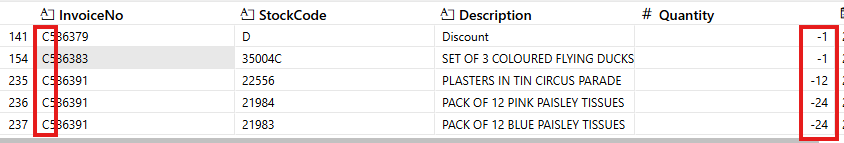

In [118]:
Image(filename='D:\\DataAnalyticsPortfolio\\datasets\\E-Commerce Data.csv\\cancellation proof.png', width=900)

<font color="green"><u>**Obs:**</u></font> As we are seeing in the above picture, any InvoiceNo that starts with the <u>letter 'C'</u> has a <u>Negative Quantity</u>, this explains our guess was <u>spot on</u>.

In [119]:
# Create a new column "IsCancelled" to indicate whether the invoice is cancelled or not
df_clean["IsCancelled"] = df_clean["InvoiceNo"].astype(str).str.startswith("C")

# Count the number of cancelled and non-cancelled invoices
df_clean["IsCancelled"].value_counts()

IsCancelled
False    532621
True       9288
Name: count, dtype: int64

In [120]:
# Analyze the number of cancelled invoices with negative quantity
df_clean[df_clean["Quantity"] < 0].shape[0]

10624

In [121]:
# Analyze the number of  not cancelled invoices with negative quantity
df_clean[(df_clean["Quantity"] < 0) & (df_clean["IsCancelled"] == False)].shape[0]

1336

In [122]:
# summary table for 
# All negative quantities
# cancelled invoices with negative quantity,
# not cancelled invoices with negative quantity
summary_table = pd.DataFrame({
    "Type": [
        "All negative quantities",
        "Cancelled invoices with negative quantity",
        "not cancelled invoices with negative quantity"
    ],
    "Count": [
        df_clean[df_clean["Quantity"] < 0].shape[0],
        df_clean[(df_clean["Quantity"] < 0) &
            (df_clean["IsCancelled"] == True)].shape[0],
        df_clean[
            (df_clean["Quantity"] < 0) &
            (df_clean["IsCancelled"] == False)
        ].shape[0]
    ]
})
summary_table

,Type,Count
0,All negative quantities,10624
1,Cancelled invoices with negative quantity,9288
2,not cancelled invoices with negative quantity,1336


**We still miss the interpretation of <font color='red'><u>over one thousand negative values</u></font>.**
<br>Let's extract them.

In [123]:
not_cancelled_negative_qty = df_clean[
    (df_clean["Quantity"] < 0) &
    (df_clean["IsCancelled"] == False)
]

not_cancelled_negative_qty

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,<NA>,United Kingdom,False
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,<NA>,United Kingdom,False
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,<NA>,United Kingdom,False
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,<NA>,United Kingdom,False
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,<NA>,United Kingdom,False
...,...,...,...,...,...,...,...,...,...
535333,581210,23395,check,-26,2011-12-07 18:36:00,0.0,<NA>,United Kingdom,False
535335,581212,22578,lost,-1050,2011-12-07 18:38:00,0.0,<NA>,United Kingdom,False
535336,581213,22576,check,-30,2011-12-07 18:38:00,0.0,<NA>,United Kingdom,False
536908,581226,23090,missing,-338,2011-12-08 09:56:00,0.0,<NA>,United Kingdom,False


In [124]:
summary = pd.DataFrame({
    "Condition": [
        "UnitPrice = 0",
        "Missing CustomerID"
    ],
    "Count": [
        (not_cancelled_negative_qty["UnitPrice"] == 0).sum(),
        not_cancelled_negative_qty["CustomerID"].isna().sum()
    ]
})
summary

,Condition,Count
0,UnitPrice = 0,1336
1,Missing CustomerID,1336


In [125]:
different_descriptions = pd.DataFrame({
    "Description": not_cancelled_negative_qty["Description"].unique()
} )  
different_descriptions

,Description
0,NaN
1,?
2,check
3,damages
4,faulty
...,...
134,wet
135,wet boxes
136,????damages????
137,mixed up


**A very valuable finding**, These descriptions strongly suggest that many of those rows are operational/internal records, not real customer sales.<br>
These descriptions likely represent <u>operational records</u> such as `damaged goods`, `returns`, or `inventory adjustments` rather than customer <br>purchases. This type of data is common in retail systems to `ensure accurate stock and accounting records`.

#### Revenue, Business Damage

In [126]:
# Create a new column "Revenue" by multiplying "Quantity" and "UnitPrice"
df_clean["Revenue"] = (df_clean["Quantity"] * df_clean["UnitPrice"]).round(4)
# Display the first few rows of the relevant columns to verify the new "Revenue" column
df_clean[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [127]:
total_revenue = df_clean["Revenue"].sum()

cancelled_revenue = df_clean.loc[
    df_clean["IsCancelled"] == True,
    "Revenue"
].sum()


In [128]:
revenue_summary = pd.DataFrame({
    "Revenue Type": ["Total Revenue", "Cancelled Revenue"],
    "Amount": [total_revenue, abs(cancelled_revenue)],
    "percentage %": [100, (abs(cancelled_revenue) / total_revenue * 100).round(4)]
})
revenue_summary

,Revenue Type,Amount,percentage %
0,Total Revenue,9747747.934,100.0000
1,Cancelled Revenue,896812.490,9.2002


In [129]:
kpis = pd.DataFrame({
    "We have": [
        "Total Rows",
        "Unique Invoices",
        "Unique Customers",
        "Unique Products",
        "Cancelled Orders",
        "Net transactional revenue",
        "Cancelled Revenue Impact"
    ],
    "Value": [
        len(df_clean),
        df_clean["InvoiceNo"].nunique(),
        df_clean["CustomerID"].nunique(),
        df_clean["StockCode"].nunique(),
        df_clean["IsCancelled"].sum(),
        total_revenue,
        abs(cancelled_revenue)
    ]
})

kpis

,We have,Value
0,Total Rows,541909.000
1,Unique Invoices,25900.000
2,Unique Customers,4372.000
3,Unique Products,4070.000
4,Cancelled Orders,9288.000
5,Net transactional revenue,9747747.934
6,Cancelled Revenue Impact,896812.490


<font color='red'>**High cancellation**</font> rates can `reduce revenue`, `disrupt inventory planning`, and `increase operational costs`. They may also indicate **problems** such as `stock shortages`, `shipping delays`, `payment issues`, or poor `customer experience`. If cancellations continue to grow, forecasting demand becomes less reliable and profitability can decline.

Businesses <font color='red'>must monitor cancellation rates</font> to measure operational performance and customer satisfaction. An increase in cancellations can help identify issues in `fulfillment`, `inventory management`, `pricing`, or `product quality`. Monitoring this metric helps companies `reduce revenue loss` and `improve business` processes.

And we must not forget that missing `CustomerID` values make it `difficult to track` customer `behavior` across transactions. Analysts cannot accurately measure repeat purchases, retention, customer lifetime value, or customer segmentation. This reduces the reliability of customer-focused analysis and business decisions.

And we must be sure that `anomalies like these` should `not be removed immediately` because they may represent **important business events** rather than errors. Unusual values can reveal _fraud, operational problems, or rare customer behavior_. **_Deleting them too early may remove valuable information and lead to incorrect conclusions._**


#### Save clean vision inside Data Folder

cleaning data

- protecting KPI integrity
- preventing false business conclusions
- preserving operational signals
- preparing trustworthy analytics

In [130]:
df_clean.to_csv("../data/ecommerce_clean_data.csv", index=False)

<hr>

## <font color="tomato">  Analytical Dataset<font>

**valid sales dataframe**

In [131]:
# Create a valid sales dataframe that includes only non-cancelled orders with positive quantity and unit price
sales_df = df_clean[
    (df_clean["Quantity"] > 0) &
    (df_clean["UnitPrice"] > 0) &
    (df_clean["IsCancelled"] == False)
].copy()

In [132]:
print("Valid sales rows:", sales_df.shape[0])
print("Valid invoices:", sales_df["InvoiceNo"].nunique())



Valid sales rows: 530104
Valid invoices: 19960


In [133]:
sales_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34


In [134]:
comparison = pd.DataFrame({
    "Dataset": [
        "Original Dataset",
        "Valid Sales Dataset",
        "Difference"
    ],
    "Rows": [
        len(df_clean),
        len(sales_df),
        len(df_clean) - len(sales_df)
    ],
    "Percentage": [
        100,
        round(len(sales_df) / len(df_clean) * 100, 2),
        round(((len(df_clean) - len(sales_df)) / len(df_clean) * 100), 2)
    ]
})

comparison

,Dataset,Rows,Percentage
0,Original Dataset,541909,100.00
1,Valid Sales Dataset,530104,97.82
2,Difference,11805,2.18


<font color='red'>**Obs:**</font> Based on what we've seen before, the row count `decreased` because records associated with `cancelled` or `invalid transactions` were _excluded from the dataset_ for this analysis. Removing these questionable invoices helps ensure that the results reflect actual sales activity and produces more reliable business insights.

In [135]:
sales_df["InvoiceDate"] = pd.to_datetime(sales_df["InvoiceDate"])
#print("The data type of 'InvoiceDate' after conversion is:", sales_df["InvoiceDate"].dtype)
sales_df["Year"] = sales_df["InvoiceDate"].dt.year
sales_df["Month"] = sales_df["InvoiceDate"].dt.month
sales_df["MonthName"] = sales_df["InvoiceDate"].dt.month_name()
sales_df["Day"] = sales_df["InvoiceDate"].dt.day
sales_df["DayOfWeek"] = sales_df["InvoiceDate"].dt.day_name()
sales_df["Hour"] = sales_df["InvoiceDate"].dt.hour

In [136]:
sales_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,Revenue,Year,Month,MonthName,Day,DayOfWeek,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False,15.30,2010,12,December,1,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34,2010,12,December,1,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False,22.00,2010,12,December,1,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34,2010,12,December,1,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34,2010,12,December,1,Wednesday,8


**Monthly Revenue**

In [137]:
monthly_revenue = (
    sales_df
    .groupby(["Year", "Month", "MonthName"])["Revenue"]
    .sum()
    .reset_index()
    .sort_values(["Year", "Month"])
)
#Use the format_number function to format the "Revenue" column in a more readable way
monthly_revenue["FormattedRevenue"] = monthly_revenue["Revenue"].apply(format_number)
monthly_revenue

,Year,Month,MonthName,Revenue,FormattedRevenue
0,2010,12,December,823746.140,823.7K
1,2011,1,January,691364.560,691.4K
2,2011,2,February,523631.890,523.6K
3,2011,3,March,717639.360,717.6K
4,2011,4,April,537808.621,537.8K
5,2011,5,May,770536.020,770.5K
6,2011,6,June,761739.900,761.7K
7,2011,7,July,719221.191,719.2K
8,2011,8,August,759138.380,759.1K
9,2011,9,September,1058590.172,1.1M


**Year-Month Plot comparison**

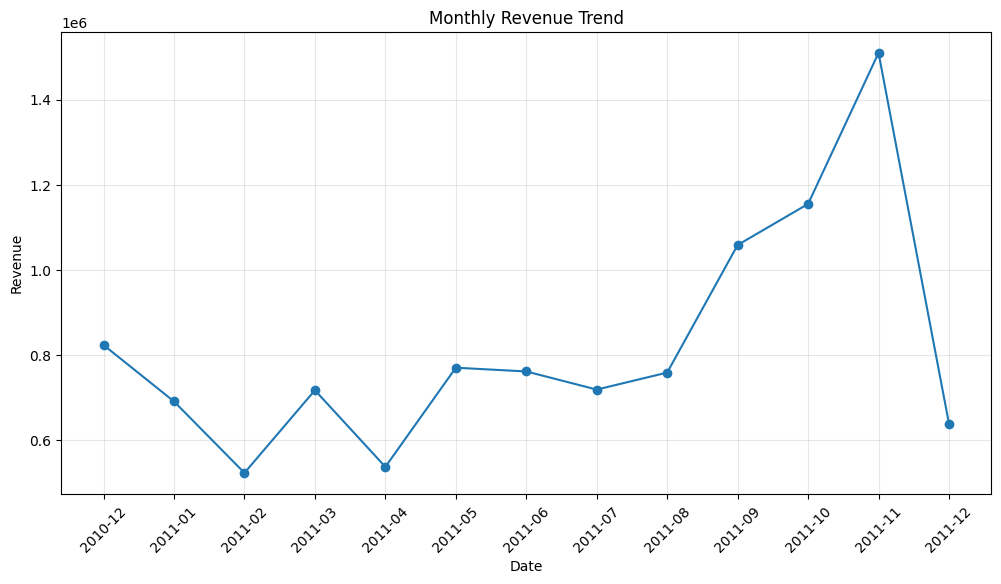

In [138]:
# Create a new column "YearMonth" by combining the "Year" and "Month" columns in the format "YYYY-MM"
monthly_revenue["YearMonth"] = (
    monthly_revenue["Year"].astype(str)
    + "-"
    + monthly_revenue["Month"].astype(str).str.zfill(2)
)
#------------------------------------------------------------------------------
# sets the size of the plot to 12 inches in width and 6 inches in height.
plt.figure(figsize=(12,6))
#------------------------------------------------------------------------------
# defines the 
# x-axis values as the "YearMonth" column
# the y-axis values as the "Revenue" column from the monthly_revenue DataFrame. 
# The marker="o" argument adds circular markers to each data point on the line plot.
plt.plot(
    monthly_revenue["YearMonth"],
    monthly_revenue["Revenue"],
    marker="o"
)
#------------------------------------------------------------------------------
# sets the title of the plot
plt.title("Monthly Revenue Trend")
#------------------------------------------------------------------------------
#sets the label for the x-axis to "Date"
plt.xlabel("Date")
#------------------------------------------------------------------------------
#set the label for the y-axis to "Revenue"
plt.ylabel("Revenue")
#------------------------------------------------------------------------------
#xticks(rotation=45) rotates the x-axis labels by 45 degrees.
plt.xticks(rotation=45)
#------------------------------------------------------------------------------
#alpha controls the transparency of the grid lines
# lower -> more transparent, higher -> more opaque.
plt.grid(alpha=0.3)
#------------------------------------------------------------------------------
# Display the plot
plt.show()
#------------------------------------------------------------------------------

**Year-over-year Plot comparison**

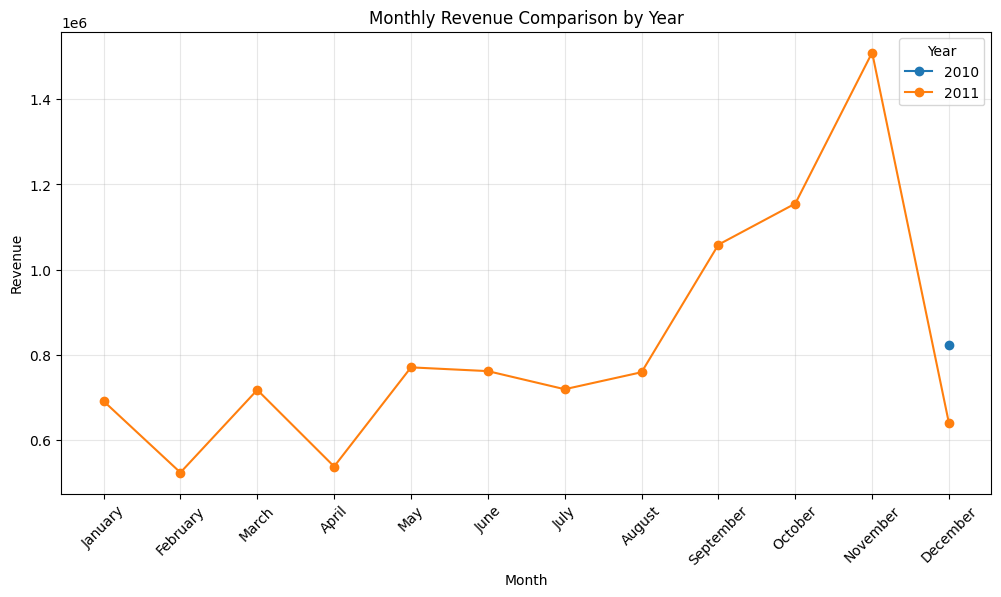

In [139]:
# pivot() to restructure the dataset so each year becomes a separate column, making it 
# easier to compare monthly revenue trends between years on the same chart
pivot_df = monthly_revenue.pivot(
    index="MonthName",
    columns="Year",
    values="Revenue"
)
# We must ensure that the months are in the correct order for plotting, so 
# we will reindex the pivoted DataFrame using a predefined list of month names
# I chosed to use the month names instead of month numbers for better readability in the plot
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]
#------------------------------------------------------------------------------
# Reindex the pivoted DataFrame to ensure the months are in the correct order for plotting
pivot_df = pivot_df.reindex(month_order)
#------------------------------------------------------------------------------
# sets the size of the plot to 12 inches in width and 6 inches in height.
plt.figure(figsize=(12,6))
#------------------------------------------------------------------------------
# Loop through each year column in the pivoted DataFrame and plot the monthly revenue 
# for that year on the same chart. Each line will represent a different year, allowing for 
# easy comparison of monthly revenue trends across years.

# We can't observe different here (in this case) because we only have one complete year of 
# data (2011), and one single month in 2010 (December) but this code is structured to handle 
# multiple years if they were present in the dataset.
for year in pivot_df.columns:
    plt.plot(
        pivot_df.index, # the x-axis values are the month names (the index of the pivoted DataFrame)
        pivot_df[year], # the y-axis values are the revenue for that year
        marker="o",     # adds circular markers to each data point on the line plot
        label=year      # the label for the legend, which will be the year (the column name in the pivoted DataFrame)
    )
#------------------------------------------------------------------------------
# sets the title of the plot
plt.title("Monthly Revenue Comparison by Year")
#------------------------------------------------------------------------------
#sets the label for the x-axis to "Month"
plt.xlabel("Month")
#------------------------------------------------------------------------------
#set the label for the y-axis to "Revenue"
plt.ylabel("Revenue")
#------------------------------------------------------------------------------
# rotates the x-axis labels by 45 degrees
plt.xticks(rotation=45)
#------------------------------------------------------------------------------
# adds a legend to the plot, with the title "Year" to indicate that each line represents a different year.
plt.legend(title="Year")
#------------------------------------------------------------------------------
#alpha controls the transparency of the grid lines
# lower -> more transparent, higher -> more opaque.
plt.grid(alpha=0.3)
#------------------------------------------------------------------------------
# Display the plot
plt.show()
#------------------------------------------------------------------------------

**From the plot:**<br>
Strongest month:
- November (2011) is clearly the peak.
- It’s the highest revenue point in the entire chart (~1.5M).<br>

Weakest month
- February (2011) looks like the lowest (~520K).
- April is also weak, but February is the minimum.

**Holiday season effects** is very clear

- Strong ramp-up starts around September
- Peaks in October → November
- Then drops in December

That pattern is classic retail behavior:

- pre-holiday buying spike (Q4 demand surge)
- Black Friday / early holiday shopping driving November peak
- December drop often happens because:
    - purchases shift earlier
    - stock issues / fulfillment delays
    - partial month effect depending on dataset cutoff

**Why this is important, and we should care about it:**
- Inventory planning → avoid stockouts in Sep–Nov
- Staffing & logistics → scale operations for peak months
- Marketing timing → spend more before the spike, not after
- Cash flow forecasting → Q4 dominates yearly revenue
- Risk control → understand weak months (Feb–Apr) for optimization

**Monthly Issues**

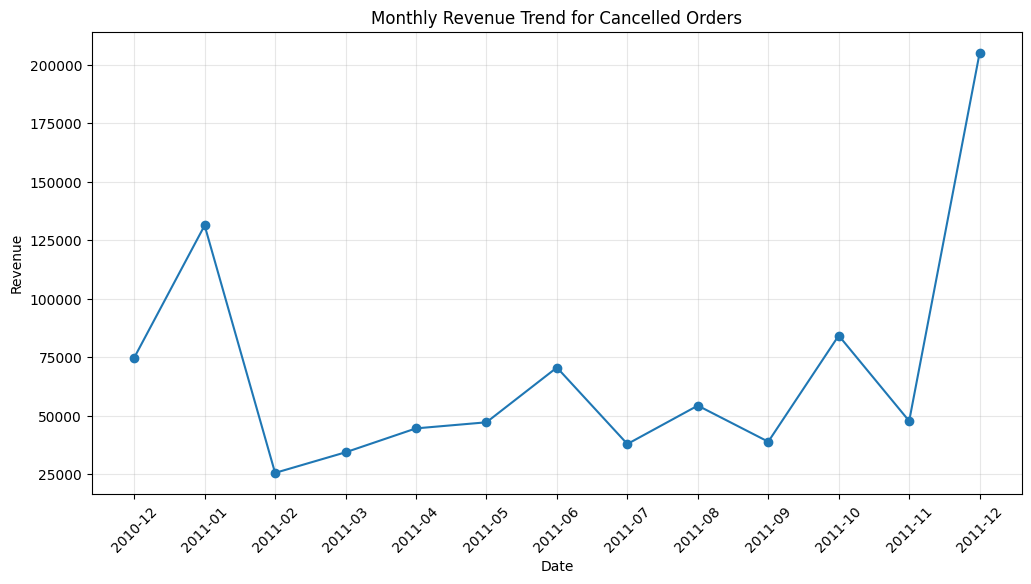

In [140]:
# Now let's analyze the revenue trend for the cancelled orders to understand their impact 
# on the overall revenue and identify any patterns or insights related to cancellations.

# We will filter the cleaned dataframe to include only the cancelled orders, and then we'll 
# perform similar date-based feature engineering to analyze the revenue trend for these 
# cancelled orders over time.
issues_df = df_clean[
    (df_clean["IsCancelled"] == True)
].copy()

# Convert "InvoiceDate" to datetime format and extract date-based features
issues_df["InvoiceDate"] = pd.to_datetime(issues_df["InvoiceDate"])

# Extracting date-based features from "InvoiceDate" to analyze trends over time
issues_df["Year"] = issues_df["InvoiceDate"].dt.year
issues_df["Month"] = issues_df["InvoiceDate"].dt.month
issues_df["MonthName"] = issues_df["InvoiceDate"].dt.month_name()
issues_df["Day"] = issues_df["InvoiceDate"].dt.day
issues_df["DayOfWeek"] = issues_df["InvoiceDate"].dt.day_name()
issues_df["Hour"] = issues_df["InvoiceDate"].dt.hour

# Create a new column "YearMonth" by combining the "Year" and "Month" columns in the format "YYYY-MM"
issues_df["YearMonth"] = (
    issues_df["Year"].astype(str)
    + "-"
    + issues_df["Month"].astype(str).str.zfill(2)
)

# Group the cancelled orders by "Year", "Month", and "YearMonth" to calculate the total revenue for
# each month, which will help us analyze the revenue trend for the cancelled orders over time.
monthly_issues = (
    issues_df
    .groupby(["Year", "Month", "YearMonth"])["Revenue"]
    .sum()
    .reset_index()
    .sort_values(["Year", "Month"])
)



#------------------------------------------------------------------------------
# sets the size of the plot to 12 inches in width and 6 inches in height.
plt.figure(figsize=(12,6))
#------------------------------------------------------------------------------
plt.plot(
    monthly_issues["YearMonth"],
    monthly_issues["Revenue"].abs(), # we take the absolute value of revenue to show the magnitude of cancellations without negative signs
    marker="o"
)
#------------------------------------------------------------------------------
# sets the title of the plot
plt.title("Monthly Revenue Trend for Cancelled Orders")
#------------------------------------------------------------------------------
#sets the label for the x-axis to "Date"
plt.xlabel("Date")
#------------------------------------------------------------------------------
#set the label for the y-axis to "Revenue"
plt.ylabel("Revenue")
#------------------------------------------------------------------------------
#xticks(rotation=45) rotates the x-axis labels by 45 degrees.
plt.xticks(rotation=45)
#------------------------------------------------------------------------------
#alpha controls the transparency of the grid lines
# lower -> more transparent, higher -> more opaque.
plt.grid(alpha=0.3)
#------------------------------------------------------------------------------
# Display the plot
plt.show()


In [141]:
# Now let's summarize the Key Performance Indicators (KPIs) that are relevant for the [executive audience], 
# focusing on 
# 1- the overall revenue performance
# 2- the impact of cancellations
# 3- the scale of valid sales transactions.
#--------------------------------------------------------------------------------------------------------------
# Calculate the KPIs
#--------------------------------------------------------------------------------------------------------------
# 1. Gross Sales Revenue: The total revenue generated from all sales before accounting for cancellations.
gross_sales_revenue = sales_df["Revenue"].sum()
#--------------------------------------------------------------------------------------------------------------
# 2. Net Transactional Revenue: The total revenue generated from all valid sales transactions.
net_transactional_revenue = df_clean["Revenue"].sum()
#--------------------------------------------------------------------------------------------------------------
# 3. Revenue Reversed by Cancellations: The total revenue lost due to cancellations. This is calculated by summing 
# the revenue of all cancelled orders (where "IsCancelled" is True) and taking the absolute value to represent the 
# magnitude of the revenue impact without negative signs.
revenue_reversed_by_cancellations = abs(
    df_clean.loc[df_clean["IsCancelled"] == True, "Revenue"].sum()
)
#--------------------------------------------------------------------------------------------------------------
# 4. Valid Sales Orders: The total number of unique invoices that represent valid sales transactions (non-cancelled 
# orders with positive quantity and unit price). This is calculated by counting the number of unique "InvoiceNo" 
# in the sales_df, which contains
valid_sales_orders = sales_df["InvoiceNo"].nunique()
#--------------------------------------------------------------------------------------------------------------
# Create a DataFrame to summarize the KPIs for the executive audience, including the KPI names and corresponding 
# values. We will also format the values using the format_number function for better readability.
executive_kpis = pd.DataFrame({
    "KPI": [
        "Gross Sales Revenue",
        "Net Transactional Revenue",
        "Revenue Reversed by Cancellations",
        "Valid Sales Orders",
        "Valid Sales Rows",
        "Unique Customers",
        "Unique Products"
    ],
    "Value": [
        gross_sales_revenue,
        net_transactional_revenue,
        revenue_reversed_by_cancellations,
        valid_sales_orders,
        len(sales_df),
        sales_df["CustomerID"].nunique(),
        sales_df["StockCode"].nunique()
    ]
})
#--------------------------------------------------------------------------------------------------------------
# Format the KPI values using the format_number function for better readability in the executive summary.
executive_kpis["Formatted Value"] = executive_kpis["Value"].apply(format_number)
#--------------------------------------------------------------------------------------------------------------
# Display the executive KPIs
executive_kpis
#--------------------------------------------------------------------------------------------------------------

,KPI,Value,Formatted Value
0,Gross Sales Revenue,1.066668e+07,10.7M
1,Net Transactional Revenue,9.747748e+06,9.7M
2,Revenue Reversed by Cancellations,8.968125e+05,896.8K
3,Valid Sales Orders,1.996000e+04,20.0K
4,Valid Sales Rows,5.301040e+05,530.1K
5,Unique Customers,4.338000e+03,4.3K
6,Unique Products,3.922000e+03,3.9K


#### **Executive KPI Interpretation**

The business generated over **$10.66M in gross sales revenue**, but after cancellations and adjustments, net transactional revenue dropped to approximately **$9.75M**.

Cancellations reversed around **$896.8K**, which is a significant operational and revenue-control issue.

The dataset contains **19,960 valid sales orders**, **530,104 valid sales rows**, **4,338 customers**, and **3,922 products**, giving enough transaction depth for customer segmentation, product analysis, and revenue trend analysis.

<hr>

## <font color="tomato">III. RFM Customer Segmentation</font>
behavioral analytics -> Recency, Frequency and Monetary

RFM Customer Segmentation

RFM (Recency, Frequency, Monetary) analysis is a powerful technique used in customer segmentation to evaluate and categorize customers based on their purchasing behavior.
In RFM analysis, customers are segmented based on three key metrics:
1. Recency <font color='green'>(**Lower is better**)</font>: How recently a customer made a purchase. This is calculated as the number of days since the customer's last purchase, using the snapshot date as a reference point.
2. Frequency <font color='green'>(**Higher is better**)</font>: How often a customer makes a purchase. This is calculated as the number of unique invoices associated with the customer.
3. Monetary <font color='green'>(**Higher is better**)</font>: How much revenue a customer has generated. This is calculated as the total revenue generated by the customer across all their purchases.

In [142]:
# To ensure that our analysis is based on the most recent invoice data, we will determine 
# the snapshot date, which is the day after the latest invoice date in our dataset
# This snapshot date will serve as a reference point for our analysis and reporting.
# We added one day to the maximum invoice date to get 1 recency factor for someone's  purchasing on that day
snapshot_date = sales_df["InvoiceDate"].max() + pd.Timedelta(days=1) # Timedelta is used to add a specific time duration to date.
snapshot_date

Timestamp('2011-12-10 12:50:00')

**RFM Table**

In [143]:
# We will calculate the RFM metrics for each customer by grouping the sales_df by "CustomerID"
# and applying the appropriate aggregation functions to compute Recency, Frequency, and Monetary values.
rfm = sales_df.groupby("CustomerID").agg({ # CustomerID
    "InvoiceDate": lambda purchDates: (snapshot_date - purchDates.max()).days, # recency
    "InvoiceNo": "nunique", # frequency
    "Revenue": "sum" # monetary
}).reset_index()
#--------------------------------------------------------------------------------------------------------------
# Rename the columns of the RFM DataFrame for better clarity
rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]
#--------------------------------------------------------------------------------------------------------------
rfm.head()
#--------------------------------------------------------------------------------------------------------------

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


Now let's analyze the distribution of the RFM metrics to understand the customer behavior and identify any patterns or insights related to recency, frequency, and monetary value.


In [144]:
# Analyze the distribution of the RFM metrics using the describe() function.
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [145]:
desc = rfm.describe()
from IPython.display import display
#--------------------------------------------------------------------------------------------------------------
# Recency Summary
#--------------------------------------------------------------------------------------------------------------

recency_summary = pd.DataFrame({
    "": [
        "Count",
        "Mean",
        "Std Dev",
        "Min",
        "25%",
        "50%",
        "75%",
        "Max"
    ],
    "Value": [
        desc.loc["count", "Recency"],
        desc.loc["mean", "Recency"],
        desc.loc["std", "Recency"],
        desc.loc["min", "Recency"],
        desc.loc["25%", "Recency"],
        desc.loc["50%", "Recency"],
        desc.loc["75%", "Recency"],
        desc.loc["max", "Recency"],
    ],

    "Explanation": [
        "Total number of customers",
        "Average days since last purchase",
        "Variation/spread in recency values",
        "Smallest recency value",
        "25% of customers purchased within this many days",
        "Median recency value",
        "75% of customers purchased within this many days",
        "Largest recency value"
    ]
}).set_index("")
styled_table = recency_summary.style.set_properties(**{
    'font-size': '18px',
    'text-align': 'left'
}).set_table_styles([
        {
            'selector': 'th',
            'props': [('font-size', '18px'), ('text-align', 'left')]
        }
    ])
display(styled_table)

,Value,Explanation
,,
Count,4338.000000,Total number of customers
Mean,92.536422,Average days since last purchase
Std Dev,100.014169,Variation/spread in recency values
Min,1.000000,Smallest recency value
25%,18.000000,25% of customers purchased within this many days
50%,51.000000,Median recency value
75%,142.000000,75% of customers purchased within this many days
Max,374.000000,Largest recency value


In [146]:
#--------------------------------------------------------------------------------------------------------------
# Frequency Summary
#--------------------------------------------------------------------------------------------------------------

frequency_summary = pd.DataFrame({
    "": [
        "Count",
        "Mean",
        "Std Dev",
        "Min",
        "25%",
        "50%",
        "75%",
        "Max"
    ],
    "Value": [
        desc.loc["count", "Frequency"],
        desc.loc["mean", "Frequency"],
        desc.loc["std", "Frequency"],
        desc.loc["min", "Frequency"],
        desc.loc["25%", "Frequency"],
        desc.loc["50%", "Frequency"],
        desc.loc["75%", "Frequency"],
        desc.loc["max", "Frequency"],
    ],

    "Explanation": [
        "Total number of customers",
        "Average number of purchases",
        "Variation/spread in purchase frequency",
        "Minimum purchase frequency",
        "25% of customers made this many purchases or less",
        "Median purchase frequency",
        "75% of customers made this many purchases or less",
        "Maximum purchase frequency"
    ]
}).set_index("")

styled_table = frequency_summary.style.set_properties(**{
    'font-size': '18px',
    'text-align': 'left'
}).set_table_styles([
        {
            'selector': 'th',
            'props': [('font-size', '18px'), ('text-align', 'left')]
        }
    ])
display(styled_table)

,Value,Explanation
,,
Count,4338.000000,Total number of customers
Mean,4.272015,Average number of purchases
Std Dev,7.697998,Variation/spread in purchase frequency
Min,1.000000,Minimum purchase frequency
25%,1.000000,25% of customers made this many purchases or less
50%,2.000000,Median purchase frequency
75%,5.000000,75% of customers made this many purchases or less
Max,209.000000,Maximum purchase frequency


In [147]:
#--------------------------------------------------------------------------------------------------------------
# Monetary Summary
# -------------------------------------------------------------------------------------------------------------

monetary_summary = pd.DataFrame({
    "": [
        "Count",
        "Mean",
        "Std Dev",
        "Min",
        "25%",
        "50%",
        "75%",
        "Max"
    ],
    "Value": [
        desc.loc["count", "Monetary"],
        desc.loc["mean", "Monetary"],
        desc.loc["std", "Monetary"],
        desc.loc["min", "Monetary"],
        desc.loc["25%", "Monetary"],
        desc.loc["50%", "Monetary"],
        desc.loc["75%", "Monetary"],
        desc.loc["max", "Monetary"],
    ],

    "Explanation": [
        "Total number of customers",
        "Average customer spending",
        "Variation/spread in spending",
        "Minimum customer spending",
        "25% of customers spent this amount or less",
        "Median customer spending",
        "75% of customers spent this amount or less",
        "Maximum customer spending"
    ]
}).set_index("")

styled_table = monetary_summary.style.set_properties(**{
    'font-size': '18px',
    'text-align': 'left'
}).set_table_styles([
        {
            'selector': 'th',
            'props': [('font-size', '18px'), ('text-align', 'left')]
        }
    ])
display(styled_table)

,Value,Explanation
,,
Count,4338.000000,Total number of customers
Mean,2054.266460,Average customer spending
Std Dev,8989.230441,Variation/spread in spending
Min,3.750000,Minimum customer spending
25%,307.415000,25% of customers spent this amount or less
50%,674.485000,Median customer spending
75%,1661.740000,75% of customers spent this amount or less
Max,280206.020000,Maximum customer spending


#### **Key business insights**

**1. Customer spending is highly uneven**

A `small group` of customers is generating a `large portion` of total revenue. This is very common in business and often<br> follows the `Pareto Principle` (**the 80/20 rule**)

`VIP customers` like these (high Frequency and high Monetary value), should be retained carefully because they are `highly valuable`.

**2. There are many inactive customers**

Some customers have not purchased in a very long time, may be some needed action like `discount offers` or `marketing and advertisements`

**3. The dataset contains strong outliers**

Especially in Monetary, this is important in later operations like clustering, scaling, or normalization, and that's because extreme values can distort the analysis.



### **Customer Segments**

In [148]:
# To create RFM segments, we will assign scores to each of the RFM metrics based on their distribution. 
# We will use the pd.qcut() function to divide each metric into quartiles and assign scores from 1 to 4, 
# where 4 represents the best customers (most recent, most frequent, highest monetary value) 
# and 1 represents the least valuable customers.
#----------------------------------------------------------------------------------------------
# For Recency, we will assign higher scores to more recent customers, 
# so we will reverse the order of the labels.
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    4,
    labels=[4,3,2,1]
)
#----------------------------------------------------------------------------------------------
# For Frequency and Monetary, we will assign higher scores to customers with higher values, 
# so we will keep the order of the labels as is.
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"), # rank(method="first") ensures that customers with the same frequency get different ranks based on their order in the dataset
    4,
    labels=[1,2,3,4]
)
#----------------------------------------------------------------------------------------------
# For Frequency and Monetary, we will assign higher scores to customers with higher values, 
# so we will keep the order of the labels as is.
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    4,
    labels=[1,2,3,4]
)
#----------------------------------------------------------------------------------------------

In [149]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)
rfm[['CustomerID', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score']].head()

,CustomerID,R_Score,F_Score,M_Score,RFM_Score
0,12346.0,1,1,4,114
1,12347.0,4,4,4,444
2,12348.0,2,3,4,234
3,12349.0,3,1,4,314
4,12350.0,1,1,2,112


In [150]:
# Function that takes a row of the RFM DataFrame and assigns a segment label based on 
# the combination of R, F, and M scores.
def segment_customer(row):
    
    if row["RFM_Score"] == "444": #Customer is in the 'top quartile' for Recency, Frequency, and Monetary value, indicating they are a highly valuable customer.
        return "VIP Customers"
    
    elif row["R_Score"] == 4: #Customer is in the 'top quartile' for Recency, indicating they are a recent customer.
        return "Recent Customers"
    
    elif row["F_Score"] == 4: #Customer is in the 'top quartile' for Frequency, indicating they are a loyal customer.
        return "Loyal Customers"
    
    elif row["M_Score"] == 4: #Customer is in the 'top quartile' for Monetary value, indicating they are big spenders.
        return "Big Spenders"
    
    else:
        return "Regular Customers"
#----------------------------------------------------------------------------------------------
# Apply the segment_customer function to each row of the RFM DataFrame to create a new "Segment" column with the assigned segment labels.
rfm["Segment"] = rfm.apply(segment_customer, axis=1)

In [151]:
# Now we will summarize the number of customers in each segment to understand 
# the distribution of our customer base across different segments.
segment_summary = (
    rfm["Segment"]
    .value_counts()
    .reset_index()
)

segment_summary

,Segment,count
0,Regular Customers,2532
1,Recent Customers,635
2,VIP Customers,490
3,Loyal Customers,476
4,Big Spenders,205


**Customer Segments bar chart**

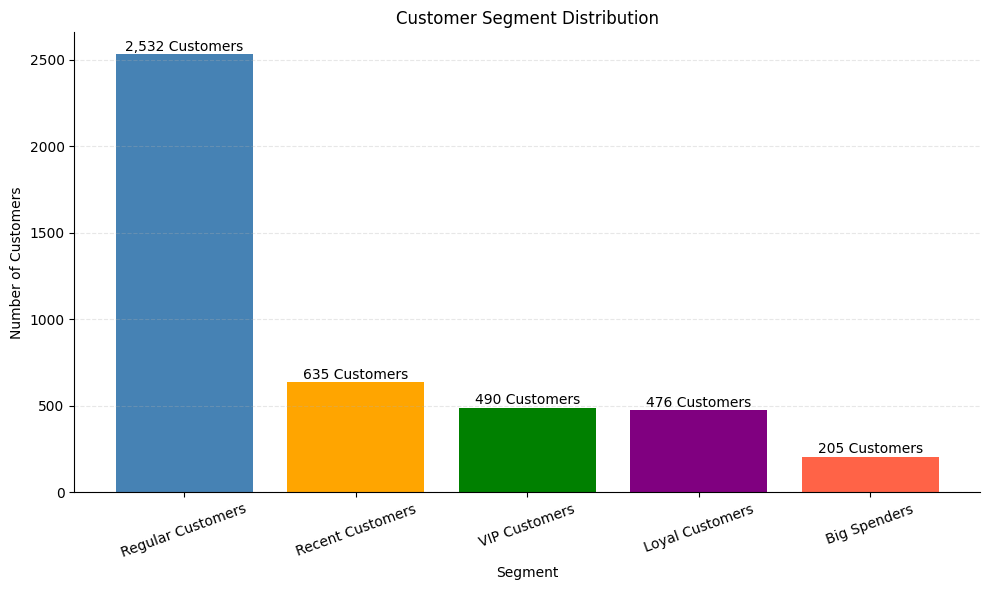

In [152]:
# Visualization of the distribution of customers across different segments.
#--------------------------------------------------------------------------------------

# sets the size of the plot to 10 inches in width and 6 inches in height.
plt.figure(figsize=(10,6))
#--------------------------------------------------------------------------------------
# Create a bar plot to visualize the distribution of customers across different segments. 
# Each bar represents a segment, and the height of the bar corresponds to the number of customers in that segment. 
# also different colors has been assigned to each segment for better visual distinction.
bars = plt.bar(
    segment_summary["Segment"],
    segment_summary["count"],
    color=[
        "steelblue",
        "orange",
        "green",
        "purple",
        "tomato"
    ]
)

#--------------------------------------------------------------------------------------
# Add value labels above bars
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 20,
        f"{height:,} Customers",
        ha='center',
        fontsize=10
    )

#--------------------------------------------------------------------------------------
plt.title("Customer Segment Distribution")

#--------------------------------------------------------------------------------------
#sets the label for the x-axis to "Segment"
plt.xlabel("Segment")

# -----------------------------
# Rotate labels
plt.xticks(rotation=20)

#--------------------------------------------------------------------------------------
#set the label for the y-axis to "Number of Customers"
plt.ylabel("Number of Customers")
#--------------------------------------------------------------------------------------
# Add grid
plt.grid(
    axis='y',
    alpha=0.3,
    linestyle='--'
)
#--------------------------------------------------------------------------------------
# Remove top/right borders
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

#--------------------------------------------------------------------------------------
# Adjust layout to prevent label cutoff
plt.tight_layout()

plt.show()



**Why is customer segmentation more powerful than averages only?**

Customer segmentation `reveals behavioral differences` between customer groups that `averages` often `hide`. It helps businesses identify `which` customer `segments drive` the most revenue, loyalty, or engagement. As a result, companies can apply more targeted strategies and deliver the appropriate marketing, retention, or promotional efforts to each customer group based on its business value.


**Loyal customers valuable even if they spend less**, because they provide stable and recurring revenue while costing less to retain than acquiring new customers.


**VIP customers dangerous to lose?**, thats because they generate a large portion of revenue despite being fewer in number. Losing them can significantly reduce profits. But:

**What risks happen if revenue depends too much on Big Spenders?**

Heavy dependence on big spenders creates revenue risk because losing a small number of customers can strongly impact the business.

Last and not least, **A Marketing should** quickly engage `recent customers` with personalized offers and follow-ups to encourage  `repeat purchases`, to turn some of them into loyal customers.

#### **Segment Revenue**

In [153]:
segment_revenue = (
    rfm.groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
segment_revenue["F-Monetary"] = segment_revenue["Monetary"].apply(format_number)

styled_table = segment_revenue.style.set_properties(**{
    'font-size': '18px',
    'text-align': 'left',
    'color': 'steelblue'
}).set_table_styles([
        {
            'selector': 'th',
            'props': [('font-size', '18px'), ('text-align', 'left'), ('color', 'gray')]
        }
    ])
display(styled_table)

,Segment,Monetary,F-Monetary
0,VIP Customers,4434743.730000,4.4M
1,Loyal Customers,1676601.790000,1.7M
2,Regular Customers,1261654.813000,1.3M
3,Recent Customers,804489.790000,804.5K
4,Big Spenders,733917.781000,733.9K


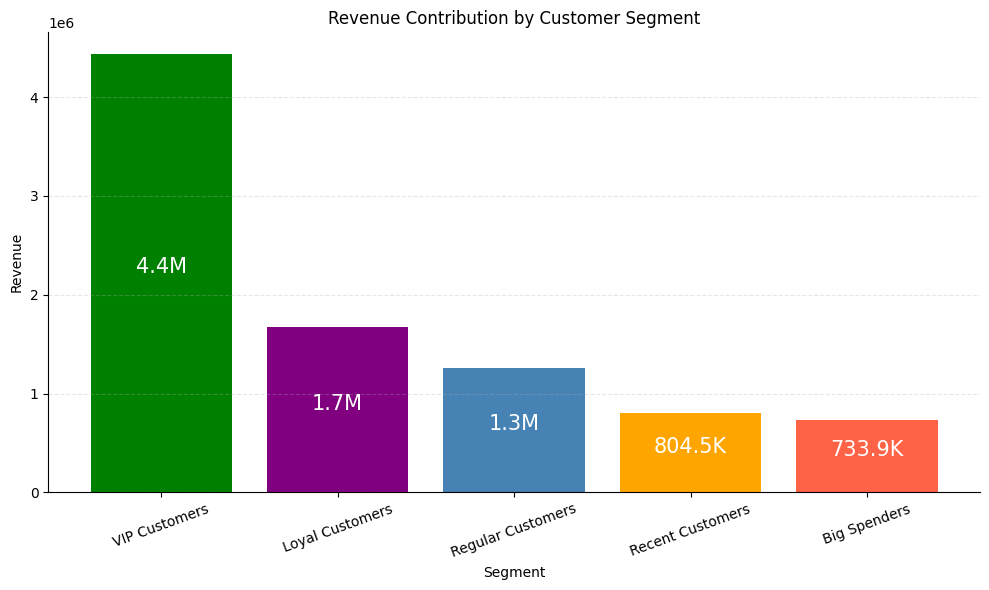

In [160]:
# sets the size of the plot to 10 inches in width and 6 inches in height.
plt.figure(figsize=(10,6))

# Create a bar plot to visualize the revenue contribution of each customer segment. 
# Each bar represents a segment, and the height of the bar corresponds to the total revenue 
# generated by that segment. Different colors are assigned to each segment for better visual distinction.
bars = plt.bar(
    segment_revenue["Segment"],
    segment_revenue["Monetary"],
    color=[
        "green",
        "purple",
        "steelblue",
        "orange",
        "tomato"
    ]   
)

#--------------------------------------------------------------------------------------
# Add value labels above bars
for i, bar in enumerate(bars):
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height/2,
        segment_revenue["F-Monetary"].iloc[i],
        ha='center',
        fontsize=15,
        color='white',
    )
    
#--------------------------------------------------------------------------------------
#-------------------- Set properties of bars --------------------
plt.xticks(rotation=20) # Rotate x-axis labels by 20 degrees for better readability

plt.title("Revenue Contribution by Customer Segment") # Set the title of the plot

plt.xlabel("Segment") # Set the label for the x-axis to "Segment"

plt.ylabel("Revenue") # Set the label for the y-axis to "Revenue"

# -----------------------------
# Add grid
plt.grid(
    axis='y',
    alpha=0.3,
    linestyle='--'
)

# -----------------------------
# Remove top/right borders
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Adjust layout to prevent label cutoff
plt.tight_layout()

plt.show()

**Inspect VIP Customers**

In [161]:
rfm[rfm["Segment"] == "VIP Customers"] \
.sort_values("Monetary", ascending=False).reset_index(drop=True) \
.head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,14646.0,2,73,280206.02,4,4,4,444,VIP Customers
1,18102.0,1,60,259657.30,4,4,4,444,VIP Customers
2,17450.0,8,46,194550.79,4,4,4,444,VIP Customers
3,14911.0,1,201,143825.06,4,4,4,444,VIP Customers
4,14156.0,10,55,117379.63,4,4,4,444,VIP Customers
5,17511.0,3,31,91062.38,4,4,4,444,VIP Customers
6,16684.0,4,28,66653.56,4,4,4,444,VIP Customers
7,14096.0,4,17,65164.79,4,4,4,444,VIP Customers
8,13694.0,4,50,65039.62,4,4,4,444,VIP Customers
9,15311.0,1,91,60767.90,4,4,4,444,VIP Customers


The table identifies VIP customers with the highest RFM score (444). These customers are highly engaged, purchase frequently, and contribute substantial revenue, making them critical to business performance and customer retention strategies.
The table also illustrates customer concentration risk, where a limited number of customers generate exceptionally high revenue compared to the average customer base.

In [162]:
segment_stats = (
    rfm.groupby("Segment")
    .agg({
        "Recency": "mean",
        "Frequency": "mean",
        "Monetary": "mean"
    })
    .round(2)
)

segment_stats

,Recency,Frequency,Monetary
Segment,,,
Big Spenders,89.26,3.02,3580.09
Loyal Customers,56.13,7.98,3522.27
Recent Customers,9.31,3.29,1266.91
Regular Customers,136.99,1.75,498.28
VIP Customers,7.43,15.51,9050.50


The table summarizes the average RFM metrics by customer segment, allowing clearer interpretation of customer behavior patterns. 

It shows that VIP Customers combine `high spending`, `high purchasing frequency`, and `recent activity`.

### Executive Observations

- **VIP Customers** spend the most on average and also purchase most frequently, making them the highest-value customer segment.

- **VIP Customers** should receive loyalty rewards and exclusive benefits to maintain retention and protect a major source of revenue.

- **Big Spenders** should receive upselling and premium product campaigns because they already demonstrate strong spending behavior.

- **Recent Customers** may represent newly acquired customers because they purchased recently but have not yet developed high purchase frequency or strong monetary value.

- **Recent Customers** should receive retention campaigns to encourage repeat purchases before engagement declines.

- **Regular Customers** appear to be the most at risk of churn due to their high recency, low purchasing frequency, and low monetary contribution.

<hr>

## <font color='tomato'>IV. Cohort Retention Analysis<font>

**Create Cohort Dataset**

In [164]:
# Cohort analysis helps analyze customer purchasing behavior over time,
# particularly customer retention and revenue generation patterns.

# A cohort is defined as a group of customers who made their first purchase
# during the same month.
#-------------------------------------------------------------------------------
# Create a copy of the sales dataset to preserve the original dataframe.
"""cohort_df = sales_df[sales_df["CustomerID"].notnull()].copy()"""

# The above code is correct but we need to make sure that the cohort_df only contains valid sales transactions 
# (non-cancelled orders with positive quantity and unit price) before we perform the cohort analysis.

cohort_df = sales_df[
    (sales_df["CustomerID"].notna()) &
    (sales_df["Quantity"] > 0) &
    (sales_df["UnitPrice"] > 0) &
    (sales_df["IsCancelled"] == False)
].copy()

#-------------------------------------------------------------------------------
# Extract the invoice year-month from the InvoiceDate column.
# Using monthly periods simplifies grouping customers by purchase month.

cohort_df["InvoiceMonth"] = (
    cohort_df["InvoiceDate"]
    .dt.to_period("M") # converts the datetime to a 'monthly period' like '2011-01', '2011-02', etc.
)

#-------------------------| customer acquisition month |------------------------
# Identify the first purchase month for each customer.
# This represents the customer's cohort month.

# groupby("CustomerID") groups transactions by customer,
# and transform("min") returns the earliest InvoiceMonth
# for every transaction belonging to that customer.

cohort_df["CohortMonth"] = (
    cohort_df.groupby("CustomerID")["InvoiceMonth"]
    .transform("min")   # transform("min") returns the minimum value of "InvoiceMonth" for each "CustomerID", 
                        # and preserves the original DataFrame's shape, allowing us to assign the cohort month to each transaction.
                        # This means that every transaction for a given customer will have the same "CohortMonth", which is the month 
                        # of their first purchase. because cohort analysis is fundamentally about 'When customers were acquired?' not 'when they left'
)

# Display the first rows of the cohort DataFrame
cohort_df[[ "CustomerID", "InvoiceMonth" , "CohortMonth"]]\
    .sort_values("InvoiceMonth", ascending=False).head()    # Sorting by InvoiceMonth in descending order to see the most recent transactions at the top.
                                                            # and to verify that the CohortMonth is correctly assigned based on the earliest InvoiceMonth for each customer.

,CustomerID,InvoiceMonth,CohortMonth
541887,15804.0,2011-12,2011-05
516423,15951.0,2011-12,2011-02
516424,15951.0,2011-12,2011-02
516425,15951.0,2011-12,2011-02
516408,15687.0,2011-12,2011-01


In [165]:
#----------------------| Cohort Index |-----------------------------------------
# Extract the `year and month` from the InvoiceMonth column.
# These values represent the transaction date components.

invoice_year = cohort_df["InvoiceMonth"].dt.year
invoice_month = cohort_df["InvoiceMonth"].dt.month

# Extract the year and month from the CohortMonth column.
# These values represent the customer's first purchase date components.
cohort_year = cohort_df["CohortMonth"].dt.year
cohort_month = cohort_df["CohortMonth"].dt.month

# Calculate the cohort index, which represents the number of months
# between the customer's first purchase and the current transaction month.
# Adding +1 ensures the first purchase month starts at index 1.

# Simply put, cohort index = the age of the customer in months since their first purchase.

cohort_df["CohortIndex"] = (
    (invoice_year - cohort_year) * 12 # Convert the year difference to months
    + (invoice_month - cohort_month)
    + 1 # Add 1 to make the cohort index start at 1 for the first purchase month
        # and the highest cohort index will be the number of months between the first 
        # purchase and the latest transaction month in the dataset.
        # which means that the max cohorty index will not depass the number of months 
        # in the dataset (which is 13 months from December 2010 to December 2011)
)

cohort_df[[ "CustomerID", "InvoiceMonth" , "CohortMonth", "CohortIndex"]]\
    .sort_values("CohortIndex", ascending=False).head() 

,CustomerID,InvoiceMonth,CohortMonth,CohortIndex
541892,13113.0,2011-12,2010-12,13
541893,13113.0,2011-12,2010-12,13
541868,13777.0,2011-12,2010-12,13
541867,13777.0,2011-12,2010-12,13
541866,13777.0,2011-12,2010-12,13


In [166]:
#------------------------| Cohort Table |---------------------------------------
# The cohort table groups customers by:
#           -> acquisition month
#           -> lifecycle month
# Group the dataset by CohortMonth and CohortIndex
# to analyze customer retention over time.

# nunique() counts the number of unique customers
# within each cohort and time period.

cohort_data = (
    cohort_df.groupby(
        ["CohortMonth", "CohortIndex"] # 
    )["CustomerID"]
    .nunique() # Count the number of unique customers in each cohort and time period and exclude duplicates and null values.
    .reset_index(name="Customer Count")
)

cohort_data

,CohortMonth,CohortIndex,Customer Count
0,2010-12,1,885
1,2010-12,2,324
2,2010-12,3,286
3,2010-12,4,340
4,2010-12,5,321
...,...,...,...
86,2011-10,2,86
87,2011-10,3,41
88,2011-11,1,323
89,2011-11,2,36


In [167]:
#------------------------| Retention Matrix |------------------------------------
# Reshape the cohort data into a matrix format
# where each row represents a cohort month
# and each column represents the cohort index.

# the reason behind this is because we are seeing the cohort index is repeating 
# for each cohort month, so we want to reshape the data to have one row per cohort 
# month and one column per cohort index, which will allow us to easily analyze 
# retention patterns over time for each cohort.

# The values in the matrix represent the number
# of unique customers retained in each period.

cohort_counts = cohort_data.pivot(
    index="CohortMonth",
    columns="CohortIndex",
    values="Customer Count" # After pivoting the data table, we will get float values because integer dtaype cannot 
                            # accommodate NaN values that may result from missing data in the pivoted table.

)


cohort_counts.style.set_properties(**{
    "text-align": "center",
    "min-width": "60px",
    "max-width": "80px",
    "width": "70px"
})


CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12,885.000000,324.000000,286.000000,340.000000,321.000000,352.000000,321.000000,309.000000,313.000000,350.000000,331.000000,445.000000,235.000000
2011-01,417.000000,92.000000,111.000000,96.000000,134.000000,120.000000,103.000000,101.000000,125.000000,136.000000,152.000000,49.000000,nan
2011-02,380.000000,71.000000,71.000000,108.000000,103.000000,94.000000,96.000000,106.000000,94.000000,116.000000,26.000000,nan,nan
2011-03,452.000000,68.000000,114.000000,90.000000,101.000000,76.000000,121.000000,104.000000,126.000000,39.000000,nan,nan,nan
2011-04,300.000000,64.000000,61.000000,63.000000,59.000000,68.000000,65.000000,78.000000,22.000000,nan,nan,nan,nan
2011-05,284.000000,54.000000,49.000000,49.000000,59.000000,66.000000,75.000000,27.000000,nan,nan,nan,nan,nan
2011-06,242.000000,42.000000,38.000000,64.000000,56.000000,81.000000,23.000000,nan,nan,nan,nan,nan,nan
2011-07,188.000000,34.000000,39.000000,42.000000,51.000000,21.000000,nan,nan,nan,nan,nan,nan,nan
2011-08,169.000000,35.000000,42.000000,41.000000,21.000000,nan,nan,nan,nan,nan,nan,nan,nan


In [168]:
#------------------------| Retention Rate |------------------------------------
# extract the cohort sizes, which represent the number of customers in each cohort at the time of acquisition (CohortIndex = 1).
# this will take the first column [0] and all rows ':'.
cohort_sizes = cohort_counts.iloc[:,0]

# Calculate the retention rate for each cohort over time.
# Each value is divided by the cohort's initial size
# to measure the percentage of customers retained
# across subsequent periods.
 # Force the HTML table layout to auto-size based on cell content

retention = cohort_counts.divide(
    cohort_sizes,
    axis=0
)

retention.style.set_properties(**{
    "width": "80px",
    "height": "30px"
})

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12,1.000000,0.366102,0.323164,0.384181,0.362712,0.397740,0.362712,0.349153,0.353672,0.395480,0.374011,0.502825,0.265537
2011-01,1.000000,0.220624,0.266187,0.230216,0.321343,0.287770,0.247002,0.242206,0.299760,0.326139,0.364508,0.117506,nan
2011-02,1.000000,0.186842,0.186842,0.284211,0.271053,0.247368,0.252632,0.278947,0.247368,0.305263,0.068421,nan,nan
2011-03,1.000000,0.150442,0.252212,0.199115,0.223451,0.168142,0.267699,0.230088,0.278761,0.086283,nan,nan,nan
2011-04,1.000000,0.213333,0.203333,0.210000,0.196667,0.226667,0.216667,0.260000,0.073333,nan,nan,nan,nan
2011-05,1.000000,0.190141,0.172535,0.172535,0.207746,0.232394,0.264085,0.095070,nan,nan,nan,nan,nan
2011-06,1.000000,0.173554,0.157025,0.264463,0.231405,0.334711,0.095041,nan,nan,nan,nan,nan,nan
2011-07,1.000000,0.180851,0.207447,0.223404,0.271277,0.111702,nan,nan,nan,nan,nan,nan,nan
2011-08,1.000000,0.207101,0.248521,0.242604,0.124260,nan,nan,nan,nan,nan,nan,nan,nan


In [170]:
#------------------------| Save DataFrames to CSV |------------------------------------
sales_df.to_csv(
    "../data/final_sales_data.csv",
    index=False
)

rfm.to_csv(
    "../data/rfm_customers.csv",
    index=False
)

retention.to_csv(
    "../data/retention_matrix.csv",
    index=False
)

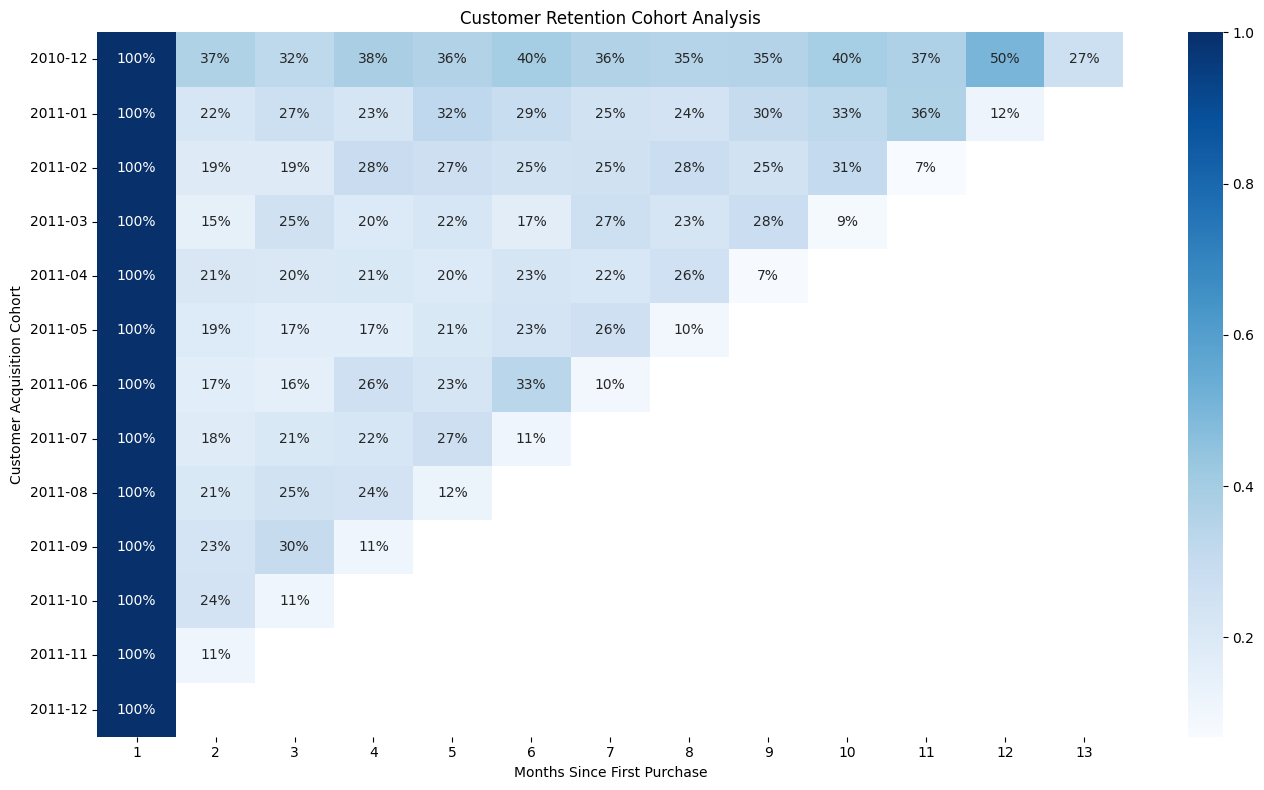

In [171]:
import seaborn as sns
plt.figure(figsize=(14,8))

sns.heatmap(
    retention,      # the retention matrix we calculated.
    annot=True,     # annot=True adds the retention rate values as annotations on the heatmap cells.
    fmt=".0%",      # fmt=".0%" formats the annotation text to display as percentages with no decimal places.
    cmap="Blues"    # cmap="Blues" sets the color scheme of the heatmap to a gradient of blue shades, 
                    # where darker blues represent higher retention rates and lighter blues represent lower retention rates.
)

# Set the title and labels for the plot
plt.title("Customer Retention Cohort Analysis")

# Set the label for the x-axis to "Months Since First Purchase"
plt.xlabel("Months Since First Purchase")

# Set the label for the y-axis to "Customer Acquisition Cohort"
plt.ylabel("Customer Acquisition Cohort")

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()

### Retention Analysis Observations

- Customers do return after their first purchase, but retention `drops significantly` after the initial month across most cohorts.

- Retention `declines` rapidly within the `first 2–3 months`, indicating that a large portion of customers do not become repeat buyers.

- Retention appears to stabilize at lower levels after several months, generally fluctuating between 20%–36% for stronger cohorts.

    Despite that The final observed period shows a `sharp decline` in retention across most cohorts, with rates dropping to `nearly 11%`.
    
    may suggest `weakening customer engagement`, `external market pressure`, `operational issues`, or `reduced customer satisfaction 
    
    during that timeframe`, with declining customer engagement and satisfaction appearing to be the most likely contributing factors based 
    
    on the consistency of the drop across cohorts.

- The 2010-12 cohort retained customers `best overall`, maintaining relatively stronger retention rates across multiple periods compared 

    to later cohorts.

- `Low retention` may indicate weak customer loyalty, low product stickiness, poor post-purchase engagement, pricing dissatisfaction, or ineffective 

    retention strategies.

- `Retention is more important than acquisition alone` because acquiring customers is costly, while retained customers generate recurring revenue, 

higher 
    lifetime value, and more stable business growth.

## <font color='green'>Executive Summary</font>

- The cohort retention analysis reveals a clear decline in customer retention shortly after the initial purchase. Most cohorts experience a significant drop 

    in retention within the first few months, indicating that many customers do not transition into repeat buyers.

- Customer loyalty appears concentrated within a smaller subset of the customer base, while a large proportion of acquired customers demonstrate short-term 

    engagement only. Although some cohorts maintain moderate long-term retention levels, overall retention stability remains relatively low across later periods.

- The earlier cohorts, particularly the 2010-12 cohort, show comparatively stronger retention performance, suggesting that acquisition quality or customer 

    engagement strategies may have weakened over time for newer cohorts.

- From a business perspective, the results indicate potential challenges related to customer loyalty, repeat purchase behavior, and long-term customer lifetime 

    value. Strong acquisition alone is insufficient if newly acquired customers fail to return consistently. Improving retention strategies, post-purchase engagement, 

    and customer experience may significantly increase long-term revenue stability and profitability.